In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with문 블록을 벗어나는 순간 자동으로 conn.close()가 호출되어 안정적임

print("연결 및 쿼리 성공! 데이터 shape:", df.shape)
df.head()

연결 및 쿼리 성공! 데이터 shape: (37, 7)


C:\Users\Nopen\AppData\Local\Temp\ipykernel_23376\2114265370.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,35,짬뽕,중식,9500,4.3,송파구,2026-08-21
1,36,우동,일식,8500,4.1,강남구,2026-08-22
2,37,김밥,분식,5500,4.2,서초구,2026-08-22
3,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
4,2,치킨,치킨,22000,4.8,서초구,2026-08-02


In [2]:
# [셀 1] 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

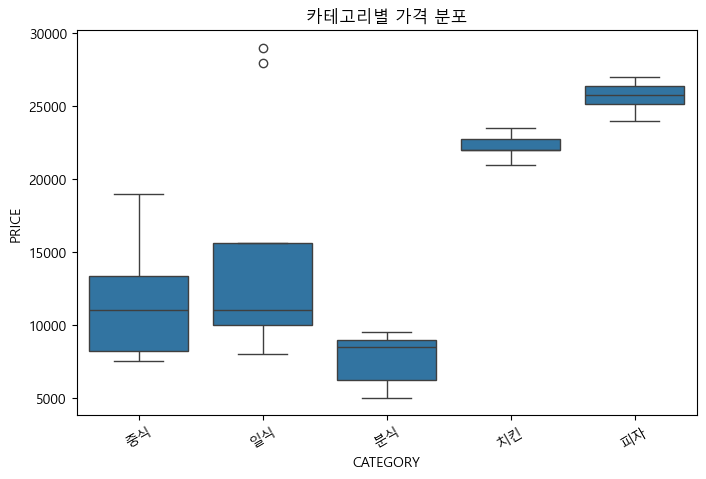

In [3]:
# [셀 2] 카테고리별 가격 분포 박스플롯 (Boxplot)
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="CATEGORY", y="PRICE")
plt.title("카테고리별 가격 분포")
plt.xticks(rotation=30)
plt.show()

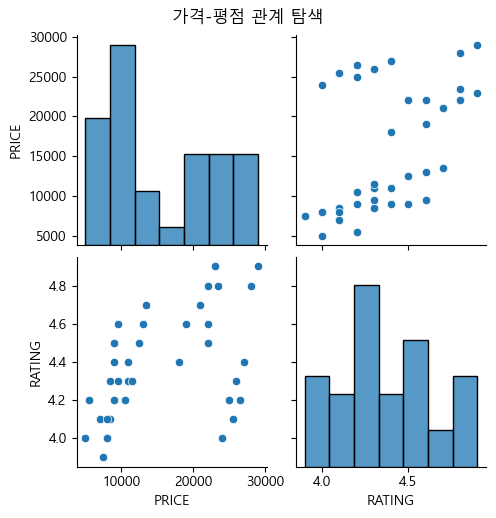

In [4]:
# [셀 3] 가격-평점 관계 탐색 페어플롯 (Pairplot)
sns.pairplot(df[["PRICE", "RATING"]])
plt.suptitle("가격-평점 관계 탐색", y=1.02)
plt.show()